In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [27]:
image = cv2.imread('sar_2.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

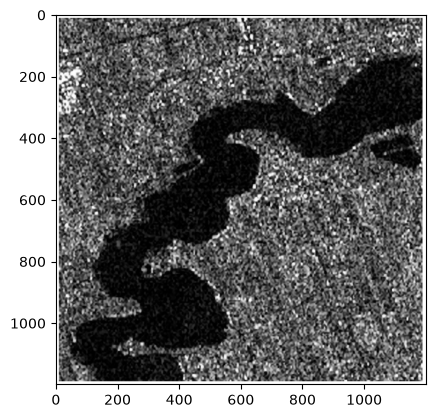

In [28]:
plt.imshow(image_gray, cmap="gray")

# Точечная бинаризация

In [29]:
import copy

bin_img = copy.deepcopy(image_gray)
T  = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

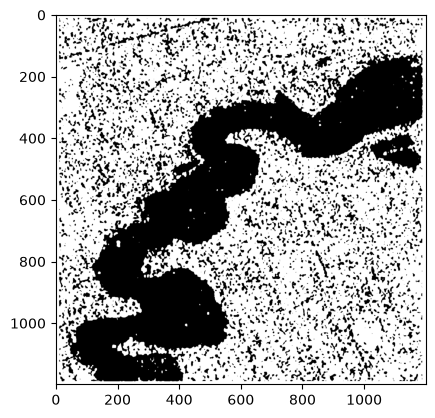

In [30]:
plt.imshow(bin_img, cmap="gray")

# Бинаризация Отсу

In [31]:
# otsu binarization
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

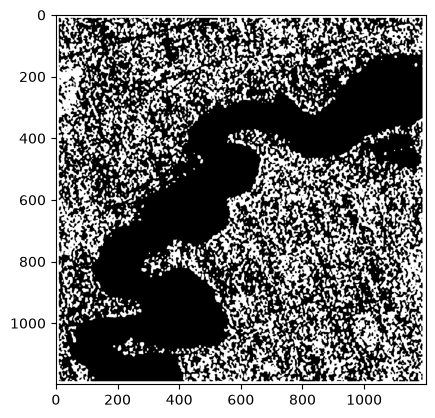

In [32]:
plt.imshow(th2, cmap="gray")

# Адаптивная бинаризация

In [33]:
# 
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)


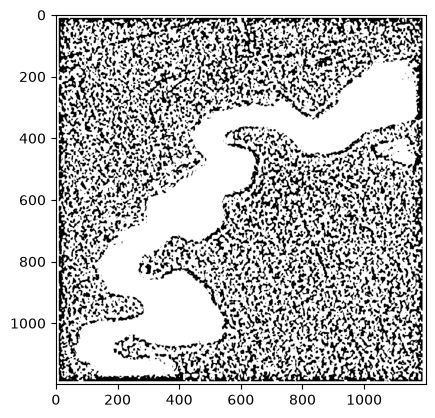

In [34]:
plt.imshow(th3, cmap="gray")

# Оператор Собеля

In [35]:
scale = 1
delta = 0
ddepth = cv2.CV_16S
grad_x = cv2.Sobel(image_gray, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad_y = cv2.Sobel(image_gray, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)

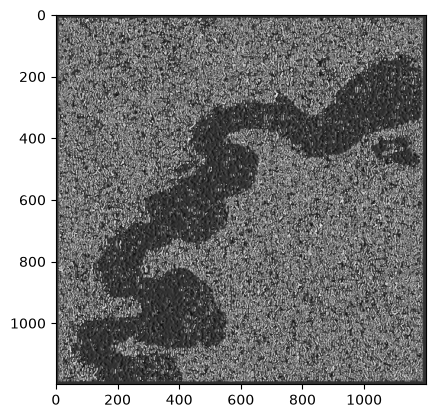

In [36]:
plt.imshow((grad_x - grad_x.min())*255, cmap="gray")

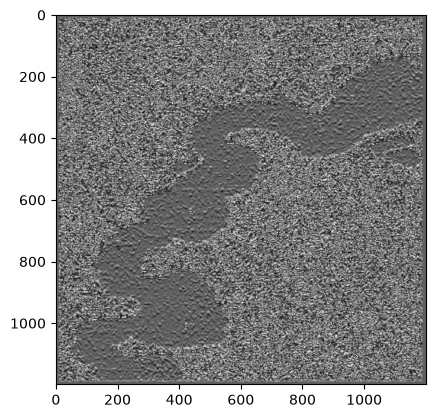

In [37]:
plt.imshow((grad_y - grad_y.min())*255, cmap="gray")

In [38]:
grad = cv2.addWeighted(grad_x, 0.5, grad_y, 0.5,0.0) # mean value between

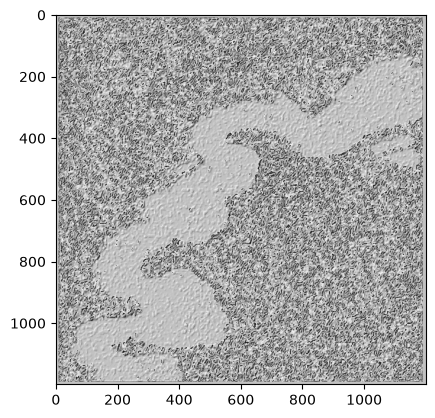

In [39]:
plt.imshow((grad - grad.min())*255, cmap="gray")

# Canny

In [40]:
edges = cv2.Canny(image_gray,100,200)

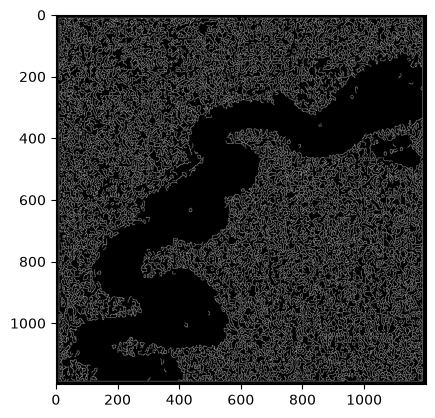

In [41]:
plt.imshow(edges, cmap="gray")

# Преобразование Хафа

In [42]:
image = cv2.imread('img_1.jpg')
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) 
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

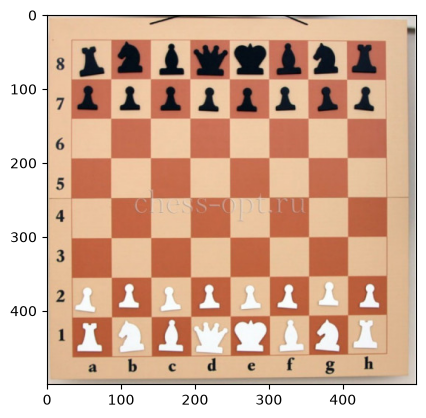

In [43]:
plt.imshow(image)

In [44]:
canny = cv2.Canny(image_gray,50,150,apertureSize = 3)

In [45]:
lines = cv2.HoughLines(canny, 1, np.pi / 180, 190)

In [46]:
import math 

if lines is not None:
        for i in range(0, len(lines)):
            rho = lines[i][0][0]
            theta = lines[i][0][1]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
            pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
            cv2.line(image, pt1, pt2, (0,0,255), 3, cv2.LINE_AA)

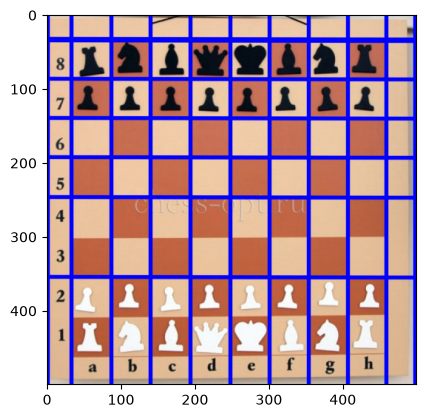

In [47]:
plt.imshow(image)

In [48]:
#ДЗ 
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

# Выполнение ДЗ — `sar_3.jpg`

1. Поиск наиболее протяжённого участка с помощью преобразования Хафа.
2. Исследование алгоритмов бинаризации и выделение участка дорожной полосы.

Размер: (225, 225)
Минимум: 0
Максимум: 255


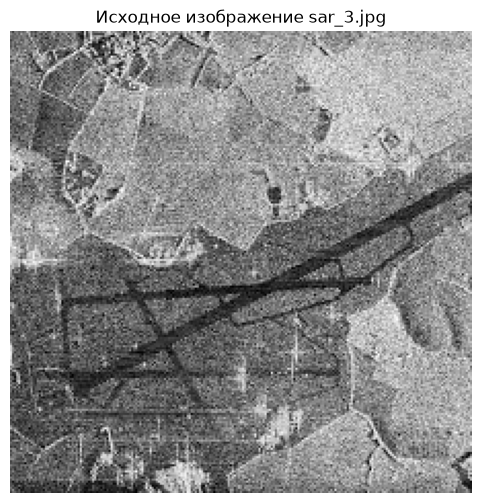

In [49]:
# Загружаем именно sar_3.jpg
image_sar3 = cv2.imread('sar_3.jpg', cv2.IMREAD_GRAYSCALE)
if image_sar3 is None:
    raise FileNotFoundError('Файл sar_3.jpg не найден')

print('Размер:', image_sar3.shape)
print('Минимум:', image_sar3.min())
print('Максимум:', image_sar3.max())

plt.figure(figsize=(6, 6))
plt.imshow(image_sar3, cmap='gray')
plt.title('Исходное изображение sar_3.jpg')
plt.axis('off')
plt.show()

## 1. Поиск наиболее протяжённого участка — преобразование Хафа

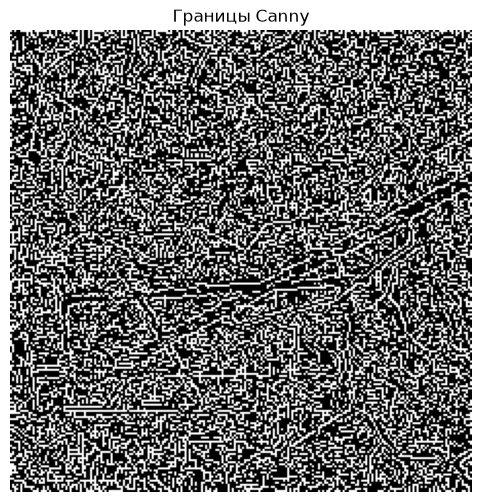

Количество найденных отрезков: 222
Наиболее протяжённый участок: (2, 224, 223, 3)
Длина участка: 312.54 пикс.
Угол наклона: -45.00°


In [50]:
# Сначала выделяем границы оператором Canny
edges_sar3 = cv2.Canny(image_sar3, 50, 150, apertureSize=3)

plt.figure(figsize=(6, 6))
plt.imshow(edges_sar3, cmap='gray')
plt.title('Границы Canny')
plt.axis('off')
plt.show()

# Преобразование Хафа для поиска отрезков
lines_p = cv2.HoughLinesP(
    edges_sar3,
    rho=1,
    theta=np.pi / 180,
    threshold=30,
    minLineLength=80,
    maxLineGap=20
)

if lines_p is None:
    raise RuntimeError('Линии Хафа не найдены')

# Находим самый длинный найденный отрезок
line_data = []

lines_array = lines_p.reshape(-1, 4)

for line in lines_array:
    x1, y1, x2, y2 = map(int, line)

    length = np.hypot(x2 - x1, y2 - y1)
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))

    line_data.append(
        (length, angle, (x1, y1, x2, y2))
    )

line_data.sort(key=lambda x: x[0], reverse=True)
best_length, best_angle, best_line = line_data[0]
x1, y1, x2, y2 = best_line

print(f'Количество найденных отрезков: {len(line_data)}')
print(f'Наиболее протяжённый участок: {best_line}')
print(f'Длина участка: {best_length:.2f} пикс.')
print(f'Угол наклона: {best_angle:.2f}°')

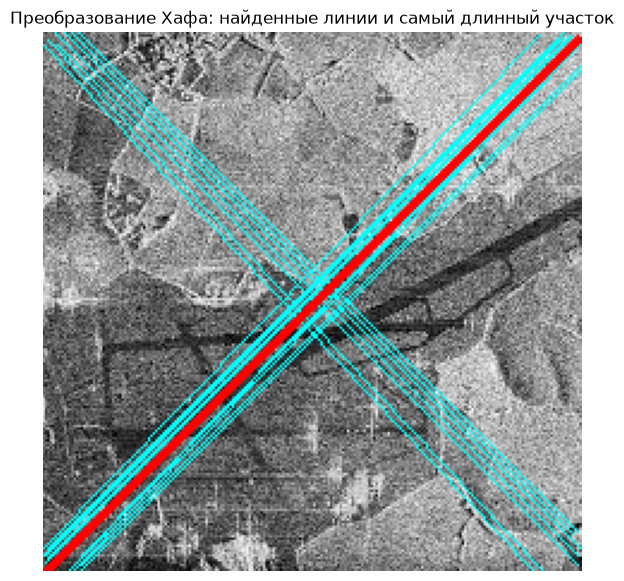

In [51]:
# Отображаем все найденные линии и отдельно самую длинную
hough_result = cv2.cvtColor(image_sar3, cv2.COLOR_GRAY2RGB)

for length, angle, (lx1, ly1, lx2, ly2) in line_data[:20]:
    cv2.line(hough_result, (lx1, ly1), (lx2, ly2), (0, 255, 255), 1)

cv2.line(hough_result, (x1, y1), (x2, y2), (255, 0, 0), 3)

plt.figure(figsize=(7, 7))
plt.imshow(hough_result)
plt.title('Преобразование Хафа: найденные линии и самый длинный участок')
plt.axis('off')
plt.show()

## 2. Исследование алгоритмов бинаризации

Проверяются точечная бинаризация с несколькими порогами, метод Отсу и адаптивная бинаризация. Для дорожной полосы дополнительно используется инверсия, так как участок дороги на исходном изображении имеет более тёмные значения.

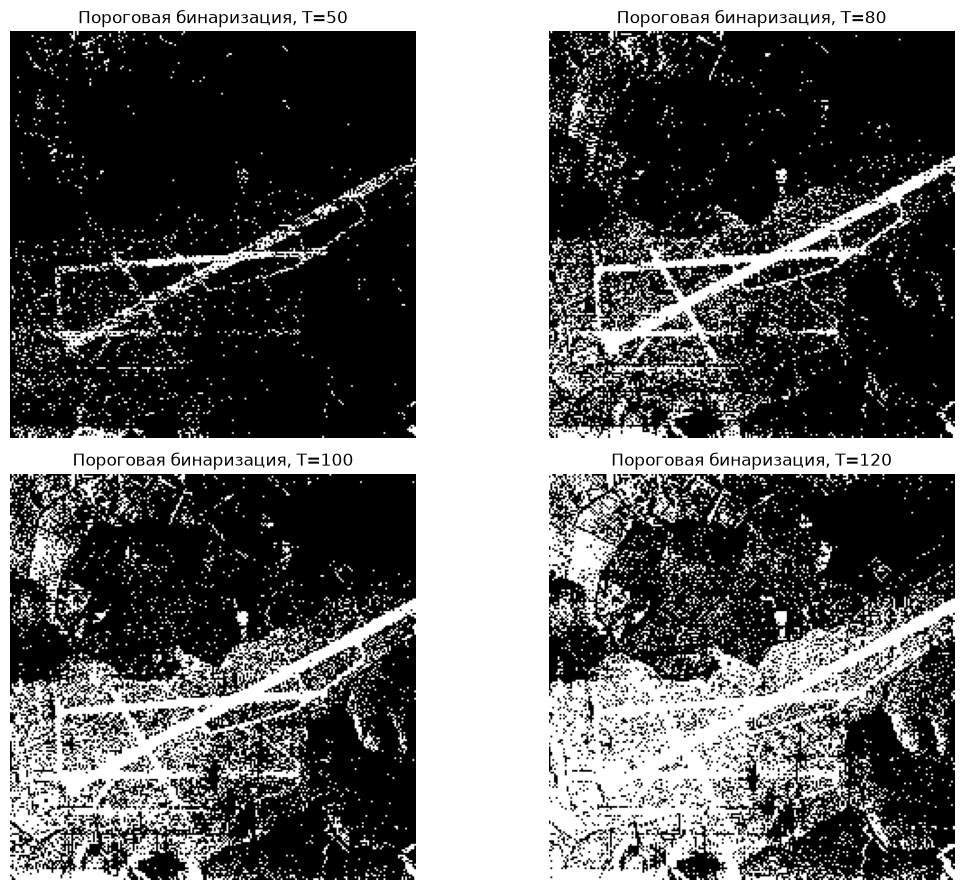

In [52]:
# Точечная бинаризация с разными порогами
thresholds = [50, 80, 100, 120]

plt.figure(figsize=(12, 9))
for i, T in enumerate(thresholds, 1):
    _, binary = cv2.threshold(image_sar3, T, 255, cv2.THRESH_BINARY_INV)
    plt.subplot(2, 2, i)
    plt.imshow(binary, cmap='gray')
    plt.title(f'Пороговая бинаризация, T={T}')
    plt.axis('off')
plt.tight_layout()
plt.show()

Автоматически найденный порог Отсу: 129


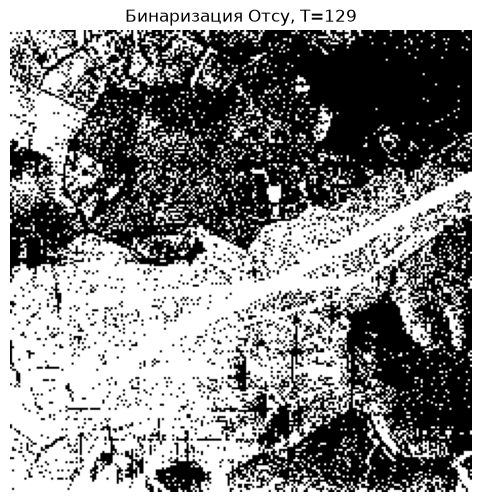

In [53]:
# Бинаризация Отсу
otsu_threshold, otsu = cv2.threshold(
    image_sar3, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(f'Автоматически найденный порог Отсу: {otsu_threshold:.0f}')

plt.figure(figsize=(6, 6))
plt.imshow(otsu, cmap='gray')
plt.title(f'Бинаризация Отсу, T={otsu_threshold:.0f}')
plt.axis('off')
plt.show()

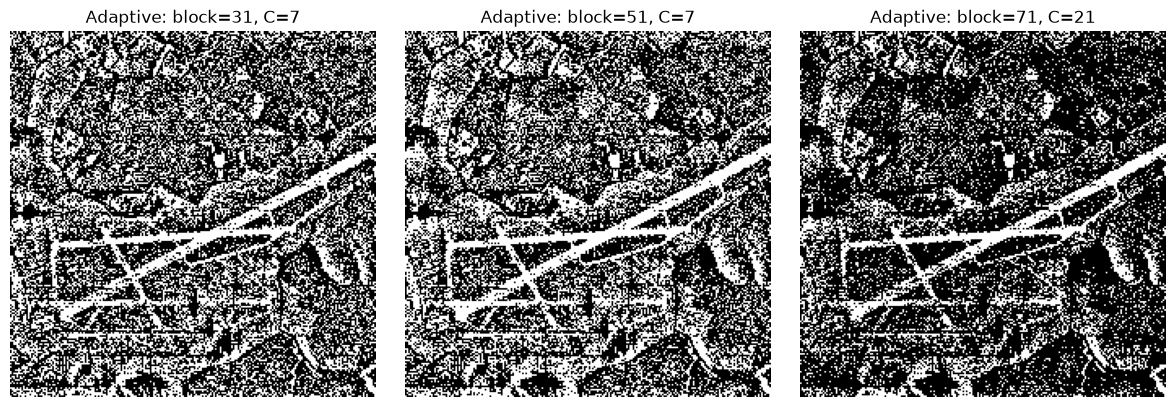

In [54]:
# Адаптивная бинаризация с разными параметрами
adaptive_params = [(31, 7), (51, 7), (71, 21)]

plt.figure(figsize=(12, 4))
for i, (block_size, C) in enumerate(adaptive_params, 1):
    adaptive = cv2.adaptiveThreshold(
        image_sar3, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        block_size, C
    )
    plt.subplot(1, 3, i)
    plt.imshow(adaptive, cmap='gray')
    plt.title(f'Adaptive: block={block_size}, C={C}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Выделение дорожной полосы

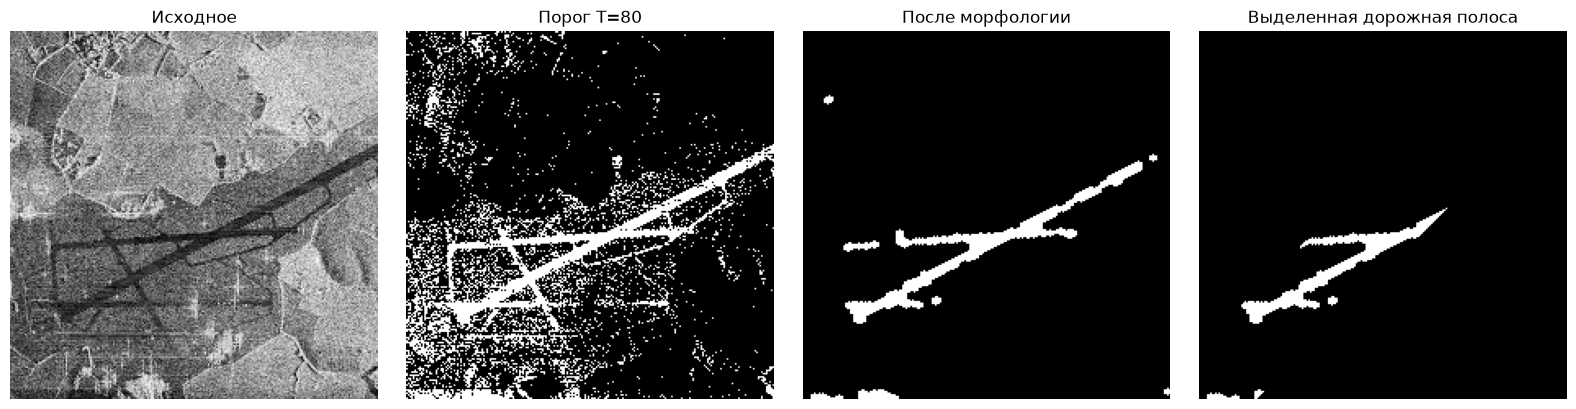

In [55]:
# Для изображения sar_3 наиболее наглядно выделяется тёмный участок дороги.
# Используем пороговую бинаризацию и морфологическую обработку для удаления мелкого шума.
road_threshold = 80
road_binary = cv2.threshold(
    image_sar3, road_threshold, 255, cv2.THRESH_BINARY_INV
)[1]

# Убираем мелкие изолированные точки и соединяем близкие элементы.
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
road_clean = cv2.morphologyEx(road_binary, cv2.MORPH_OPEN, kernel)
road_clean = cv2.morphologyEx(road_clean, cv2.MORPH_CLOSE, kernel)

# Строим полосу вокруг наиболее протяжённой линии Хафа.
road_roi = np.zeros_like(image_sar3)
cv2.line(road_roi, (x1, y1), (x2, y2), 255, 45)

# Оставляем только бинарные объекты в районе найденного участка.
road_mask = cv2.bitwise_and(road_clean, road_roi)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(image_sar3, cmap='gray')
plt.title('Исходное')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(road_binary, cmap='gray')
plt.title(f'Порог T={road_threshold}')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(road_clean, cmap='gray')
plt.title('После морфологии')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(road_mask, cmap='gray')
plt.title('Выделенная дорожная полоса')
plt.axis('off')

plt.tight_layout()
plt.show()

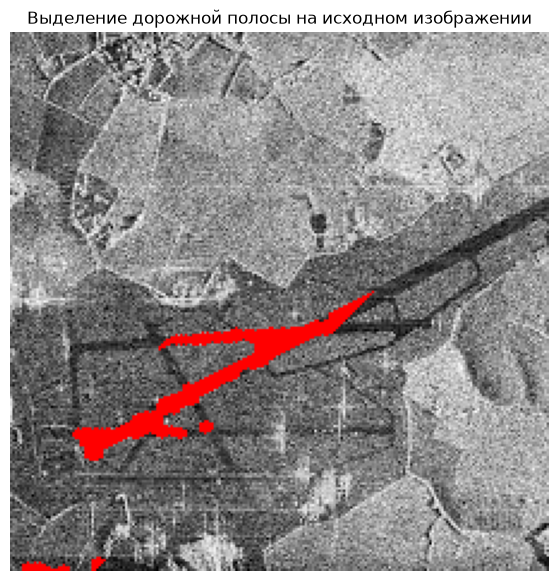

Использованный порог для выделения дороги: 80
Ширина полосы вокруг линии Хафа: 45 пикс.


In [56]:
# Наложение найденной дорожной полосы на исходное изображение
highlight = cv2.cvtColor(image_sar3, cv2.COLOR_GRAY2RGB)
highlight[road_mask > 0] = [255, 0, 0]

plt.figure(figsize=(7, 7))
plt.imshow(highlight)
plt.title('Выделение дорожной полосы на исходном изображении')
plt.axis('off')
plt.show()

print('Использованный порог для выделения дороги:', road_threshold)
print('Ширина полосы вокруг линии Хафа: 45 пикс.')